# Yelp Review Prediction - 30D1Y PRECOVID (Template Import)

This notebook imports functions from `prediction_template.ipynb` and runs the full pipeline with COVID settings.

This script examines whether early Yelp reviews predict future business ratings for the year 2015 with an early review window of 30 days.

It analyzes business-level early review features, including early average star rating, review count, reviewer bias, review word count, and reviewer profile metrics. 
The script evaluates how strongly each feature is associated with future average rating using the Pearson correlation coefficient, and then uses these features to build predictive regression models.

The script trains and compares baseline mean, linear regression, ridge regression, random forest, and XGBoost models. Model performance is evaluated using MAE, RMSE, R², and 5-fold cross-validation.

Input:
	Processed CSV file with one row per review.

Output:
	Model comparison results and correlation visualizations.

Results:
	Early average stars had the highest Pearson Correlation Coefficient r = 0.666.
	Ridge model performed the best with r^2 = 0.454, mae = 0.312, and rmse = 0.413

In [8]:
from pathlib import Path

%run ./prediction_template.ipynb

PROCESSED_DIR = Path("./processed_data")
COHORT_YEAR = 2015 
EARLY_WINDOW_DAYS = 30
FUTURE_WINDOW_END_DAY = 365
MIN_EARLY_REVIEWS = 5
MIN_FUTURE_REVIEWS = 5
PERIOD = "PRECOVID"
FEATURE_FILE = "review_features.csv"

Sanity check report
Rows: 4364
Columns: 16
Features: 14
Missing features: 0
Duplicate business_id: 0
Missing target values: 0
Missing feature values: 0
Target summary:
count    4364.000000
mean        3.849536
std         0.609929
min         1.000000
25%         3.535714
50%         3.958619
75%         4.268384
max         5.000000
dtype: float64
Regression results
               model       mae      rmse        r2  n_train  n_test  \
0  linear_regression  0.332471  0.440131  0.482205     3491     873   
1              ridge  0.332510  0.440178  0.482095     3491     873   
2      random_forest  0.341991  0.447189  0.465464     3491     873   
3            xgboost  0.345775  0.453230  0.450925     3491     873   
4      baseline_mean  0.458467  0.611680 -0.000097     3491     873   

   n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used  
0          14     0.345744    0.007980    0.434293   0.045038              5  
1          14     0.345751    0.007975    0.4

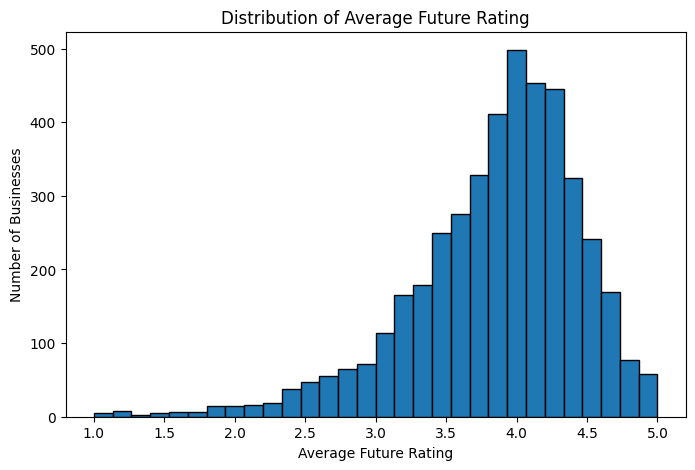

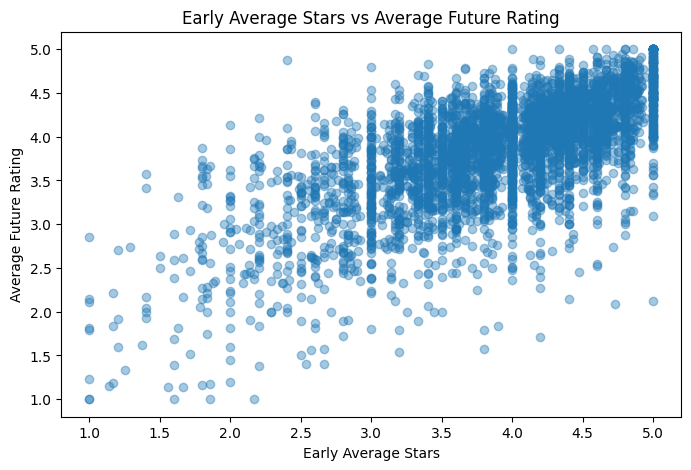

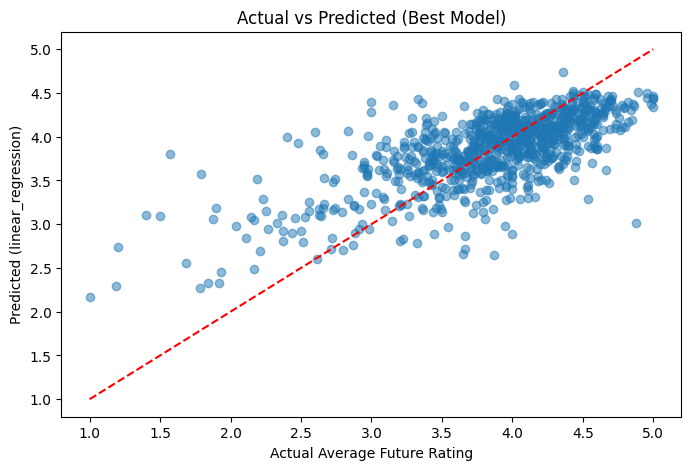

Best model: linear_regression
model            linear_regression
mae                       0.332471
rmse                      0.440131
r2                        0.482205
n_train                       3491
n_test                         873
n_features                      14
cv_mae_mean               0.345744
cv_mae_std                 0.00798
cv_r2_mean                0.434293
cv_r2_std                 0.045038
cv_folds_used                    5
Name: 0, dtype: object


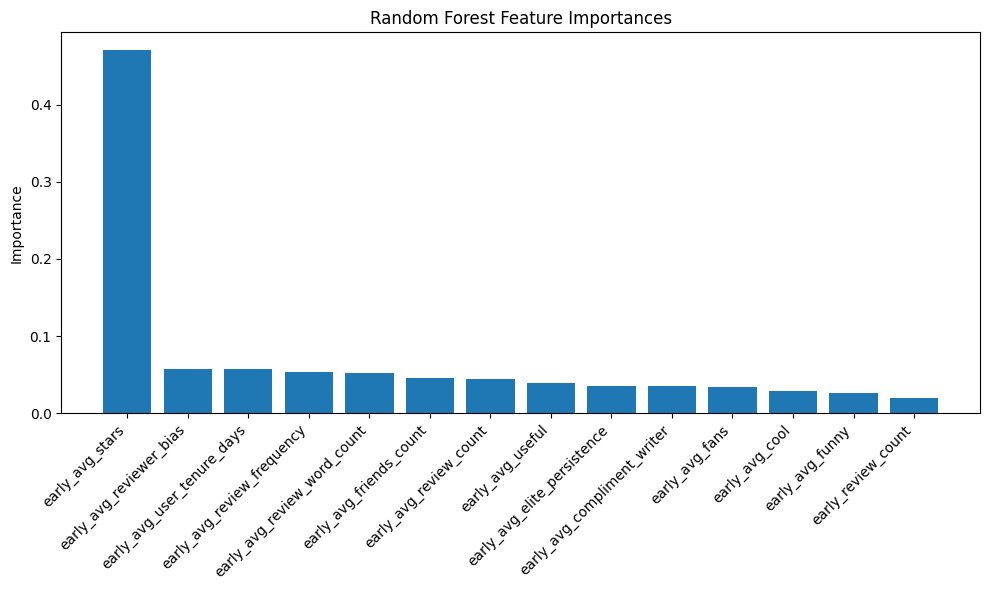

Top correlations with average_future_rating:


,feature,corr
0,early_avg_stars,0.669308
1,early_avg_reviewer_bias,0.598432
2,early_avg_cool,0.151603
3,early_avg_review_word_count,-0.133379
4,early_avg_user_tenure_days,0.122900
5,early_avg_elite_persistence,0.067110
6,early_avg_fans,0.060073
7,early_avg_friends_count,0.056853
8,early_review_count,0.050971
9,early_avg_review_count,0.028896


,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
24,-0G_6-KFGpCpxTUlVXCMYQ,3.375,0.500000,0.125000,0.125,87.375000,7.375,29.625000,3.750000,-0.391250,720.375000,1.375,98.125000,27.750000,8,3.428571
26,-0TffRSXXIlBYVbb5AwfTg,4.000,0.916667,0.083333,0.500,75.083333,5.250,68.583333,4.666667,0.166667,946.916667,1.000,142.166667,8.416667,12,4.295775
34,-0iIxySkp97WNlwK66OGWg,4.600,2.200000,0.500000,1.700,128.100000,13.200,337.700000,15.700000,0.461000,902.700000,1.800,92.000000,33.400000,10,3.745098
40,-1B9pP_CrRBJYPICE5WbRA,3.500,0.000000,0.000000,0.100,56.100000,1.800,76.700000,0.300000,-0.706000,1033.900000,0.300,85.900000,14.900000,10,3.754717
49,-1XSzguS6XLN-V6MVZMg2A,4.900,2.700000,0.200000,1.400,50.900000,4.500,116.900000,0.500000,0.765000,1275.600000,0.700,92.000000,10.200000,10,4.669231


In [9]:
pipeline_output = run_prediction_pipeline(
    processed_dir=PROCESSED_DIR,
    cohort_year=COHORT_YEAR,
    early_window_days=EARLY_WINDOW_DAYS,
    future_window_end_day=FUTURE_WINDOW_END_DAY,
    period=PERIOD,
    min_early_reviews=MIN_EARLY_REVIEWS,
    min_future_reviews=MIN_FUTURE_REVIEWS,
    feature_file=FEATURE_FILE,
)

model_df = pipeline_output["model_df"]
feature_cols = pipeline_output["feature_cols"]
target_col = pipeline_output["target_col"]

print("Model dataset shape:", model_df.shape)
print("Target column:", target_col)
print("Number of features:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])
print("Sanity report:", pipeline_output["sanity_report"])
print("Regression summary:")
print(pipeline_output["regression_report"]["results_df"])

output_dir = PROCESSED_DIR / "modeling_tables"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"business_level_{EARLY_WINDOW_DAYS}D_{FUTURE_WINDOW_END_DAY}D_{PERIOD}.csv"
model_df.to_csv(output_path, index=False, float_format="%.4f")
print("Saved modeling table to:", output_path.resolve())

results_package = generate_results_package(
    pipeline_output=pipeline_output,
    target_col=target_col,
    top_n_correlations=15,
    show_plots=True,
)

print("Top correlations with average_future_rating:")
display(results_package["correlation_table"])

model_df.head()

In [10]:
# Exploratory Tables and Graphs
# Summary stats, head, and missing values
import pandas as pd

print("Model dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nSummary statistics:")
print(model_df.describe())

print("\nMissing values per column:")
print(model_df.isnull().sum())

print("\nFirst 5 rows:")
model_df.head()

Model dataset shape: (4364, 16)

Columns:
['business_id', 'early_avg_stars', 'early_avg_useful', 'early_avg_funny', 'early_avg_cool', 'early_avg_review_count', 'early_avg_fans', 'early_avg_friends_count', 'early_avg_compliment_writer', 'early_avg_reviewer_bias', 'early_avg_user_tenure_days', 'early_avg_elite_persistence', 'early_avg_review_word_count', 'early_avg_review_frequency', 'early_review_count', 'average_future_rating']

Summary statistics:
       early_avg_stars  early_avg_useful  early_avg_funny  early_avg_cool  \
count      4364.000000       4364.000000      4364.000000     4364.000000   
mean          3.901856          1.423533         0.403753        0.588118   
std           0.734895          1.405972         0.597494        0.875546   
min           1.000000          0.000000         0.000000        0.000000   
25%           3.500000          0.500000         0.000000        0.125000   
50%           4.000000          1.000000         0.200000        0.333333   
75%     

,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
24,-0G_6-KFGpCpxTUlVXCMYQ,3.375,0.500000,0.125000,0.125,87.375000,7.375,29.625000,3.750000,-0.391250,720.375000,1.375,98.125000,27.750000,8,3.428571
26,-0TffRSXXIlBYVbb5AwfTg,4.000,0.916667,0.083333,0.500,75.083333,5.250,68.583333,4.666667,0.166667,946.916667,1.000,142.166667,8.416667,12,4.295775
34,-0iIxySkp97WNlwK66OGWg,4.600,2.200000,0.500000,1.700,128.100000,13.200,337.700000,15.700000,0.461000,902.700000,1.800,92.000000,33.400000,10,3.745098
40,-1B9pP_CrRBJYPICE5WbRA,3.500,0.000000,0.000000,0.100,56.100000,1.800,76.700000,0.300000,-0.706000,1033.900000,0.300,85.900000,14.900000,10,3.754717
49,-1XSzguS6XLN-V6MVZMg2A,4.900,2.700000,0.200000,1.400,50.900000,4.500,116.900000,0.500000,0.765000,1275.600000,0.700,92.000000,10.200000,10,4.669231


In [11]:
# Correlation with target: top features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if "average_future_rating" in numeric_cols:
    corr_series = model_df[numeric_cols].corr()["average_future_rating"].drop("average_future_rating")
    corr_top = corr_series.abs().sort_values(ascending=False).head(15)
    print("Top correlations with average_future_rating (by absolute value):")
    display(pd.DataFrame({"feature": corr_top.index, "corr": corr_top.values}))
else:
    print("average_future_rating not in numeric columns; skipping correlation summary.")

Top correlations with average_future_rating (by absolute value):


,feature,corr
0,early_avg_stars,0.669308
1,early_avg_reviewer_bias,0.598432
2,early_avg_cool,0.151603
3,early_avg_review_word_count,0.133379
4,early_avg_user_tenure_days,0.122900
5,early_avg_elite_persistence,0.067110
6,early_avg_fans,0.060073
7,early_avg_friends_count,0.056853
8,early_review_count,0.050971
9,early_avg_review_count,0.028896


ALL MODEL RESULTS
               model       mae      rmse        r2  n_train  n_test  n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used
0  linear_regression  0.332471  0.440131  0.482205     3491     873          14     0.345744    0.007980    0.434293   0.045038              5
1              ridge  0.332510  0.440178  0.482095     3491     873          14     0.345751    0.007975    0.434298   0.044997              5
2      random_forest  0.341991  0.447189  0.465464     3491     873          14     0.354432    0.008477    0.403141   0.046288              5
3            xgboost  0.345775  0.453230  0.450925     3491     873          14     0.359147    0.008324    0.387543   0.053414              5
4      baseline_mean  0.458467  0.611680 -0.000097     3491     873          14     0.466753    0.023482   -0.001637   0.001793              5



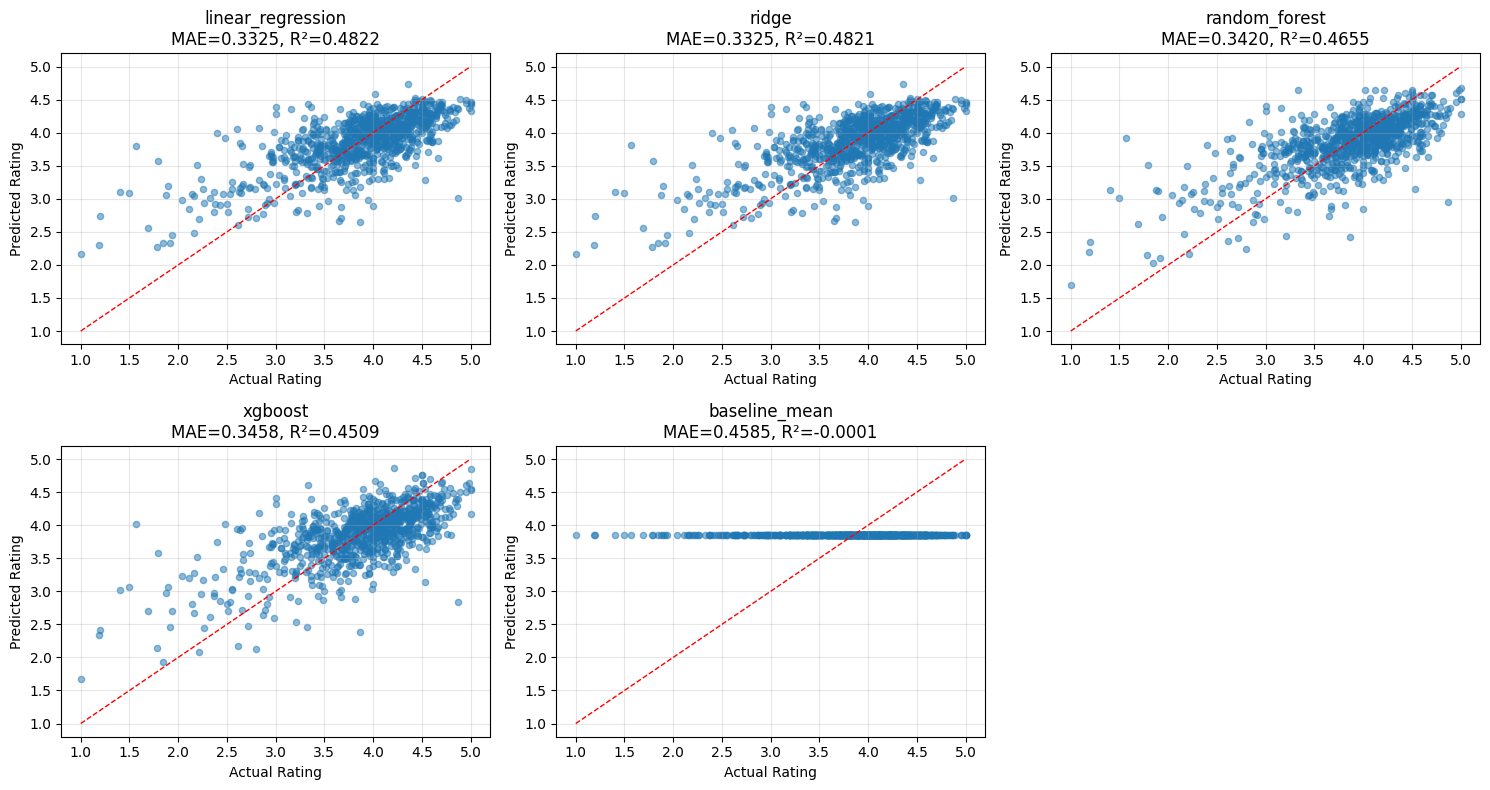

In [12]:
# Model Results: All models with predicted vs actual plots
import numpy as np

results_df = pipeline_output["regression_report"]["results_df"]
predictions_df = pipeline_output["regression_report"]["predictions_df"].copy()

print("=" * 80)
print("ALL MODEL RESULTS")
print("=" * 80)
print(results_df.to_string())
print()

y_true = predictions_df["average_future_rating"].values
min_val = float(y_true.min())
max_val = float(y_true.max())

# Plot predicted vs actual for each model
num_models = len(results_df)
n_cols = 3
n_rows = (num_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to 1D array for easier iteration

for idx, (_, row) in enumerate(results_df.iterrows()):
    model_name = row["model"]
    mae = row["mae"]
    r2 = row["r2"]
    
    # Get predictions for this model
    if model_name == "baseline_mean":
        pred_col = "pred_baseline_mean"
    else:
        pred_col = f"pred_{model_name}"
    
    if pred_col not in predictions_df.columns:
        print(f"Warning: {pred_col} not found in predictions_df")
        continue
    
    y_pred = predictions_df[pred_col].values
    
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red", linewidth=1)
    ax.set_xlabel("Actual Rating")
    ax.set_ylabel("Predicted Rating")
    ax.set_title(f"{model_name}\nMAE={mae:.4f}, R²={r2:.4f}")
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


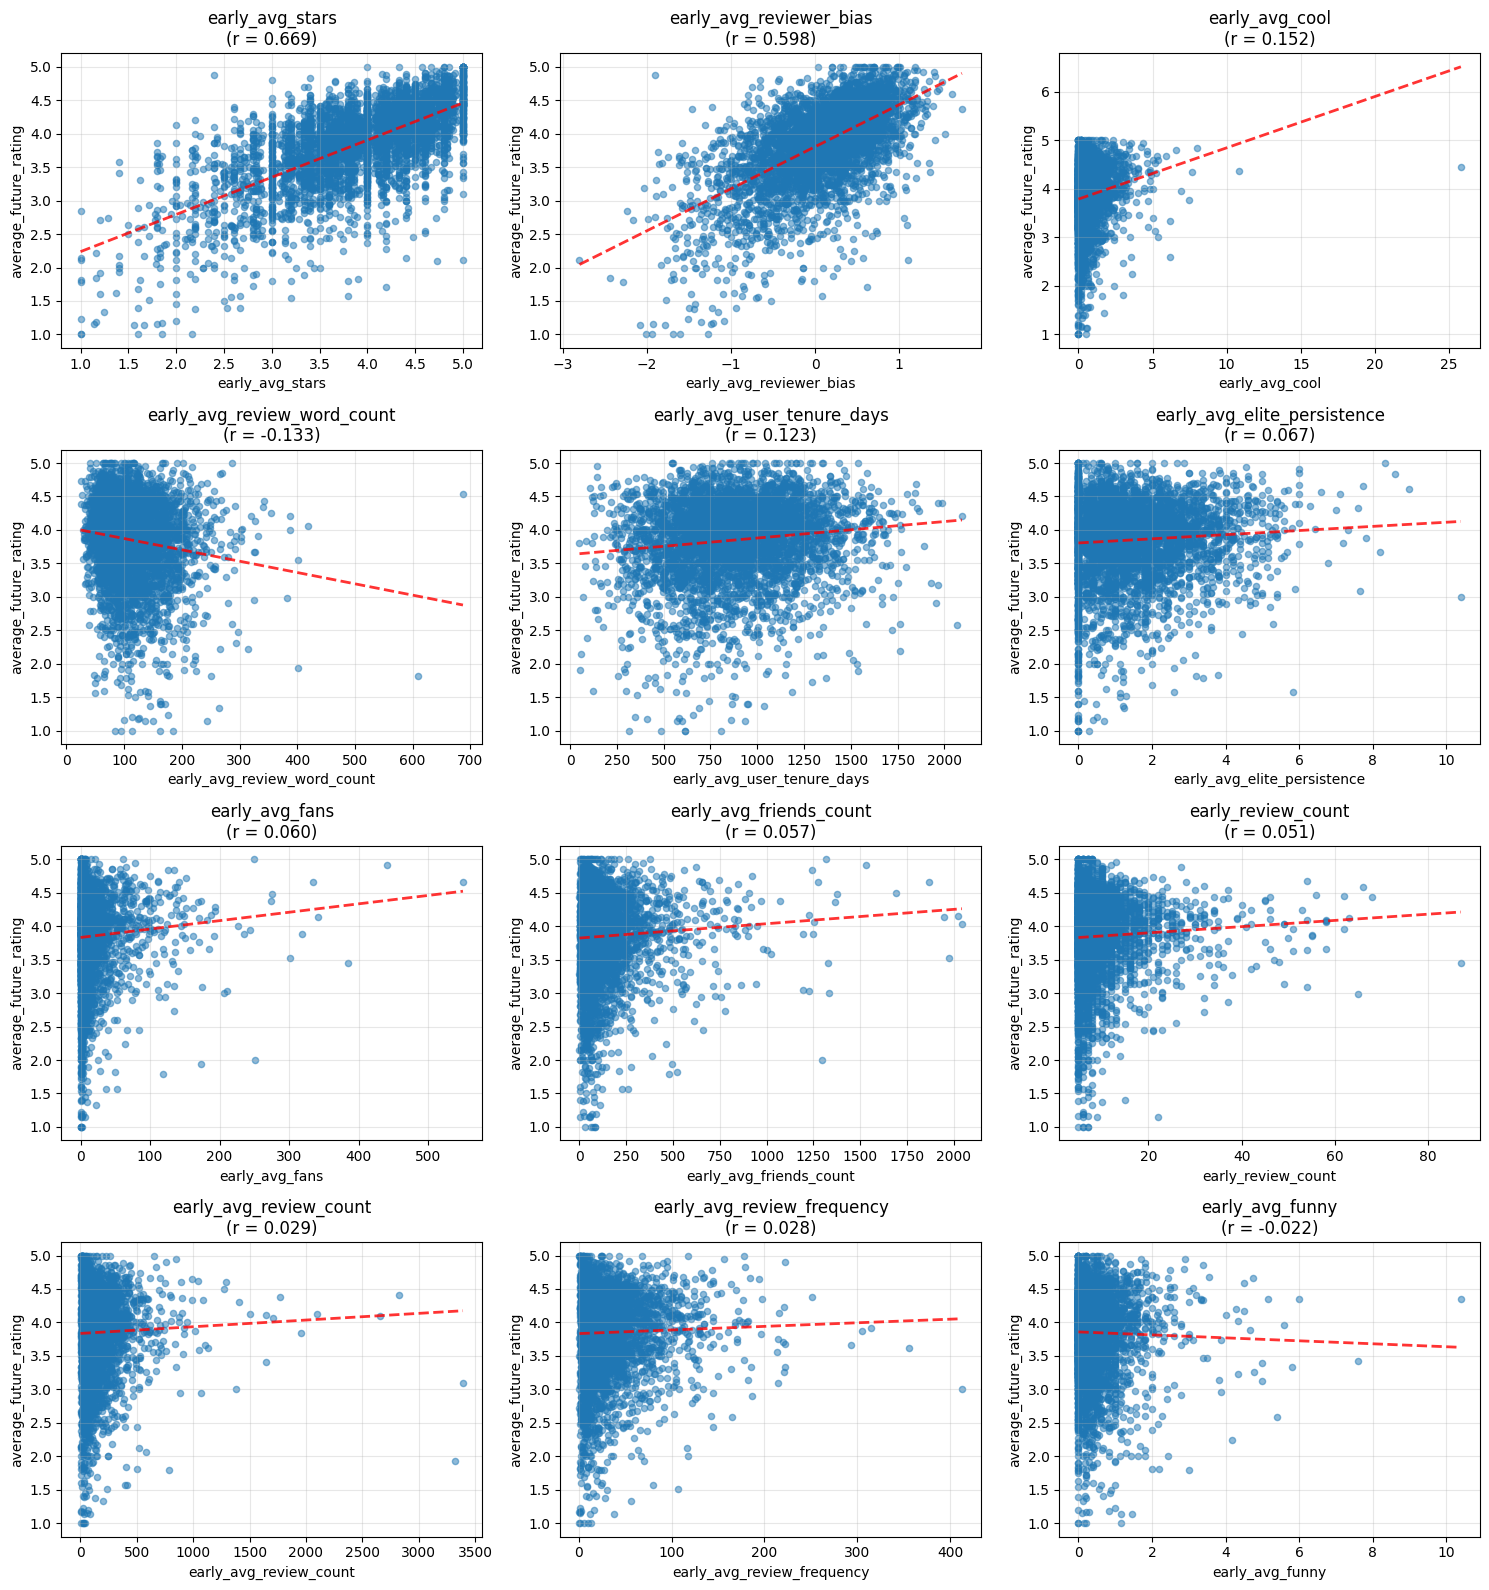

In [13]:
# Top Features vs Target Relationships
from scipy import stats

# Get top correlated features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if target_col in numeric_cols:
    corr_with_target = model_df[numeric_cols].corr()[target_col].drop(target_col)
    top_features = corr_with_target.abs().sort_values(ascending=False).head(12).index.tolist()
    
    # Create scatter plots for top features
    n_features = len(top_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for idx, feature in enumerate(top_features):
        ax = axes[idx]
        
        # Scatter plot
        ax.scatter(model_df[feature], model_df[target_col], alpha=0.5, s=20)
        
        # Add trend line
        z = np.polyfit(model_df[feature].dropna(), model_df[target_col].loc[model_df[feature].notna()], 1)
        p = np.poly1d(z)
        x_line = np.linspace(model_df[feature].min(), model_df[feature].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        # Calculate correlation
        corr_coef = corr_with_target[feature]
        
        ax.set_xlabel(feature)
        ax.set_ylabel(target_col)
        ax.set_title(f"{feature}\n(r = {corr_coef:.3f})")
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"{target_col} not in numeric columns; skipping feature vs target analysis.")
